# 4.4 Topological Constraints and Stationary Modes (Appendix A.4)

Reproduces Table 4.7 (multiplicity of $\lambda = 0$ swept over $R_m$ on the annulus and the flat torus) and Figure A.12 (the two meshes, `topo_mesh_annulus.eps`, `topo_mesh_torus.eps`). Imports the shared modules `spectral_common.py` and `annulus_mesh.py` from this folder. Run top to bottom in a kernel with Firedrake + SLEPc + MUMPS; figures are written to `./figures`.


## Setup


Matplotlib/LaTeX figure style, imports, `FIGDIR`, `show`, `show_settings`, `kappa_pair`, `save_fig`.


In [1]:
import matplotlib.pyplot as plt

# 1. Document parameters
latex_textwidth_pt = 426.79135 # REPLACE with the number you got from \the\textwidth
inches_per_pt = 1.0 / 72.27
fig_width = latex_textwidth_pt * inches_per_pt
fig_height = fig_width * 0.75 # Standard 4:3 aspect ratio, adjust as needed

base_fontsize = 11 # Or 12, depending on your document class declaration

# 2. Update rcParams globally
plt.rcParams.update({
    "figure.figsize": (fig_width, fig_height),
    
    # Match LaTeX fonts
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    
    # Match font sizes exactly
    "font.size": base_fontsize,
    "axes.titlesize": base_fontsize,
    "axes.labelsize": base_fontsize,
    "legend.fontsize": base_fontsize - 1, # Slightly smaller for legend
    "xtick.labelsize": base_fontsize - 2, # Smaller for tick marks
    "ytick.labelsize": base_fontsize - 2,
    
    # Refine line weights for a professional look
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "grid.linewidth": 0.5,
})

In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from firedrake import *
from firedrake.function import PointEvaluator
from firedrake.pyplot import triplot, tripcolor

from petsc4py import PETSc
from slepc4py import SLEPc

import spectral_common as sc
from spectral_common import (solve_pencil, border_gauge, condition_estimates,
                             rates, KAPPA_LOG)
from annulus_mesh import make_annulus_mesh

# `from firedrake import *` exports a `logging` of its own, so the standard
# library one has to be re-imported under another name afterwards.  `triplot`
# warns once per call about the boundary labels of a mesh with no exterior
# facets, which the torus has by construction.
import logging as stdlogging
stdlogging.getLogger("firedrake").setLevel(stdlogging.ERROR)
stdlogging.getLogger("tsfc").setLevel(stdlogging.ERROR)

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

# Everything the LaTeX block above does not set: fonts and sizes come from there.
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "savefig.pad_inches": 0.02})

#: A high-order measure for the diagnostics: the harmonic field of the annulus
#: goes like 1/r, and comparing against it deserves better than the default rule.
DX = dx(metadata={"quadrature_degree": 6})


def show(df, caption=None, **kw):
    """`sc.fmt_table` wired to this notebook's display function."""
    return sc.fmt_table(df, caption=caption,
                        display_fn=lambda c: display(Markdown(f"**{c}**")), **kw)


print(f"PETSc scalars: {PETSc.ScalarType.__name__}")


PETSc scalars: float64


In [3]:
half_width = fig_width * 0.49          # two panels side by side across the text
half_height = half_width * 1.05
sub_fontsize = base_fontsize - 1


def show_settings(title, S):
    r"""Render one experiment's solve settings as a table, before it is solved.

    Every experiment below opens with one of these and then reads its parameters
    straight out of it, so nothing a table reports depends on a value set in
    another cell or on a default hidden inside a function.
    """
    frame = pd.DataFrame({"setting": list(S), "value": [str(v) for v in S.values()]})
    # `show` returns the formatted frame, so it has to be displayed here: these
    # blocks are never the last expression in their cell.
    display(show(frame.set_index("setting"), default="{}", caption=title))


def kappa_pair(res):
    r"""$(\text{MUMPS COND1},\ \text{Hager }\kappa_1)$ of $A - \tau M$ for one solve."""
    return res.kappa["MUMPS COND1"], res.kappa[r"Hager $\kappa_1$"]


def save_fig(fig, name):
    r"""Write one panel to `figures/<name>.eps` and `.pdf`.

    Both, because a LaTeX `\includegraphics` given no extension prefers the
    `.pdf`, and a stale one from an earlier style would then be picked silently.
    """
    for ext in ("eps", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}")

Meshes: `torus_mesh`, `R_IN`, `R_OUT`. This cell also draws the two $n = 8$ mesh panels of Figure A.12 (`topo_mesh_annulus.eps`, `topo_mesh_torus.eps`).


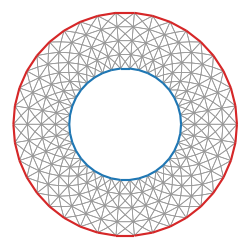

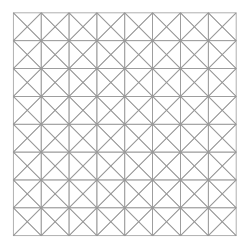

annulus:   608 cells,   76 exterior facets, markers [np.int32(1), np.int32(2)]
torus  :   256 cells,    0 exterior facets


In [4]:
N_ANN, N_TOR = 20, 16
L_TOR = 2 * np.pi
R_IN, R_OUT = 0.5, 1.0


def torus_mesh(n, L=L_TOR):
    r"""The flat torus $(\mathbb{R}/L\mathbb{Z})^2$, triangulated."""
    return PeriodicRectangleMesh(n, n, L, L,
                                 direction="both",     # periodic in x and y
                                 diagonal="crossed",
                                 quadrilateral=False)


# The two mesh panels.  No titles: the subcaptions carry the labels in the
# document.  On the annulus the outer rim is drawn red and the inner one blue.
mesh_a = make_annulus_mesh(n=8, inner_radius=R_IN, outer_radius=R_OUT)
mesh_t = torus_mesh(8)

fig, ax = plt.subplots(figsize=(half_width, half_width))
triplot(mesh_a, axes=ax, interior_kw={"linewidths": 0.5, "edgecolors": "0.6"},
        boundary_kw={"linewidths": 1.4, "colors": ["C3", "C0"]})
ax.set_aspect("equal"); ax.axis("off")
save_fig(fig, "topo_mesh_annulus")
plt.show()

fig, ax = plt.subplots(figsize=(half_width, half_width))
triplot(mesh_t, axes=ax, interior_kw={"linewidths": 0.5, "edgecolors": "0.6"})
ax.set_aspect("equal"); ax.axis("off")
save_fig(fig, "topo_mesh_torus")
plt.show()

print(f"annulus: {mesh_a.num_cells():5d} cells, "
      f"{mesh_a.exterior_facets.set.total_size:4d} exterior facets, "
      f"markers {list(mesh_a.exterior_facets.unique_markers)}")
print(f"torus  : {mesh_t.num_cells():5d} cells, "
      f"{mesh_t.exterior_facets.set.total_size:4d} exterior facets")

Formulations, `build_pencil`, the shift-and-invert solve `solve_topo` (with `zero_tol = -1` so the zeros are kept), and `zero_count`.


In [5]:
def cross2d(a, b):
    r"""Scalar 2D cross product $(a\times b)_z = a_1b_2 - a_2b_1$.

    Antisymmetric, so the ordering is load-bearing: the induction term needs
    $u\times\beta$, the proxy of the contraction $\iota^1_\beta u$.
    """
    return a[0] * b[1] - a[1] * b[0]


def space(form, mesh, r):
    """The mixed (or scalar) space of one formulation at polynomial degree r."""
    if form == "A(P)":
        return FunctionSpace(mesh, "CG", r)
    if form == "B(N1)":
        return FunctionSpace(mesh, "N1curl", r) * FunctionSpace(mesh, "CG", r)
    return FunctionSpace(mesh, "N2curl", r) * FunctionSpace(mesh, "CG", r + 1)


def _block_mean(W, sub):
    r"""The vector $g_i = \int_\Omega \phi_i$ over one block of a mixed space."""
    c = assemble(TestFunctions(W)[sub] * dx)
    with c.dat.vec_ro as v:
        return v.getArray().copy()


def build_pencil(form, mesh, r=1, beta=None, eps=Constant(1.0), closed=False):
    r"""Assemble $(A, M)$ for one formulation.  $M$ is singular in every case.

    `closed=True` selects the no-boundary variant used on the torus: no Dirichlet
    conditions, and the multiplier's constant removed by a rank-one border so
    that the pencil is regular.
    """
    if form == "A(P)":
        V = space(form, mesh, r)
        a_, z = TrialFunction(V), TestFunction(V)
        a = eps * inner(grad(a_), grad(z)) * dx
        if beta is not None:
            a = a + inner(dot(beta, grad(a_)), z) * dx
        K = assemble(a).petscmat
        M = assemble(inner(a_, z) * dx).petscmat
        # g_i = \int phi_i : the gauge (A, 1) = 0 as a rank-one border.
        g = np.asarray(assemble(TestFunction(V) * dx).dat.data_ro).copy()
        A_b, M_b = border_gauge(K, M, g)
        return A_b, M_b, V

    W = space(form, mesh, r)
    (u, q) = TrialFunctions(W)
    (v, s) = TestFunctions(W)
    a = eps * inner(curl(u), curl(v)) * dx
    if beta is not None:
        a = a + inner(cross2d(u, beta), curl(v)) * dx
    a = a + (-inner(grad(q), v) + inner(u, grad(s))) * dx
    m = inner(u, v) * dx

    if closed:
        # No boundary: the pair (0, q=const) sits in ker(A) ∩ ker(M) and makes the
        # pencil singular.  The same border that gauges A(P) fixes it here.
        A_b, M_b = border_gauge(assemble(a).petscmat, assemble(m).petscmat,
                                _block_mean(W, 1))
        return A_b, M_b, W

    # On an H(curl) space a DirichletBC constrains the TANGENTIAL trace, which is
    # the perfectly-conducting condition; q = 0 puts the multiplier in H^1_0.
    bcs = [DirichletBC(W.sub(0), Constant((0.0, 0.0)), "on_boundary"),
           DirichletBC(W.sub(1), Constant(0.0), "on_boundary")]
    # weight=0.0 gives the constrained rows a zero mass diagonal, so the boundary
    # modes go to infinity rather than to a spurious lambda = 1.
    return (assemble(a, bcs=bcs).petscmat,
            assemble(m, bcs=bcs, weight=0.0).petscmat, W)


FORMS = ["B(N1)", "B(N2)", "A(P)"]
TEX = {"B(N1)": r"$B(\mathcal{N}^{\mathrm{I}}_r)$",
       "B(N2)": r"$B(\mathcal{N}^{\mathrm{II}}_r)$",
       "A(P)":  r"$A(\mathcal{P}_r)$"}
STYLE = {"B(N1)": "C0", "B(N2)": "C1", "A(P)": "C2"}


def solve_topo(form, mesh, *, r, beta, Rm, tau, nev, n_eigs, closed, zero_tol,
               **meta):
    r"""One solve.  Every setting is required and none of them is defaulted here.

    That is deliberate: the settings block opening each experiment is then the
    whole story of how its numbers were produced, and no table can inherit a
    resolution, a degree, a Reynolds number or a shift from a neighbouring cell.

    ``zero_tol = -1`` is the point of this notebook -- `solve_pencil` discards
    $|\lambda| \le 10^{-9}$ by default, which is exactly the part of the spectrum
    being counted here, so the filter has to be switched off.  Conditioning is
    always estimated: ``res.kappa`` carries MUMPS' COND1 and the Hager
    $\kappa_1$ of $A - \tau M$, the matrix shift-and-invert actually factorises.
    """
    A, M, W = build_pencil(form, mesh, r, beta=beta, eps=Constant(1.0 / Rm),
                           closed=closed)
    return solve_pencil(A, M, tau, nev=nev, n_eigs=n_eigs, space=W,
                        zero_tol=zero_tol, cond=True,
                        form=form, r=r, Rm=Rm, **meta)


def eigenfunction(res, k):
    """The k-th eigenmode as a field: $u$ itself, or $\\nabla^{\\perp}A$ for A(P)."""
    vr, vi = res.A.createVecRight(), res.A.createVecRight()
    res.solver.getEigenvector(int(res.index[k]), vr, vi)
    arr = np.asarray(vr.getArray())
    f = Function(res.space)
    if res.meta["form"] == "A(P)":
        f.dat.data[:] = arr[:res.space.dim()]
        return f
    with f.dat.vec_wo as fv:
        fv.setArray(arr[:fv.getLocalSize()])
    return f.subfunctions[0]


def _whiten(G):
    """W with W^T G W = I, dropping numerically null directions."""
    w, V = np.linalg.eigh(G)
    keep = w > w.max() * 1e-13
    return V[:, keep] / np.sqrt(w[keep])


def subspace_error(computed, exact):
    """Sine of the largest principal angle between two $L^2$ subspaces (the gap)."""
    gram = lambda P, Q: np.array([[assemble(inner(a, b) * DX) for b in Q] for a in P])
    Wc, We = _whiten(gram(computed, computed)), _whiten(gram(exact, exact))
    sv = np.linalg.svd(Wc.T @ gram(computed, exact) @ We, compute_uv=False)
    return float(np.sqrt(max(0.0, 1.0 - min(sv.min(), 1.0) ** 2)))


def zero_count(values, *, Rm, rel):
    r"""How many eigenvalues are zero, at a threshold that scales with $\varepsilon$.

    The whole spectrum scales with $\varepsilon = 1/R_m$, so a fixed absolute
    threshold would mean different things at different Reynolds numbers.  Every
    table below also prints the largest value counted and the smallest one not,
    so the reader can see that no plausible threshold changes the answer.
    """
    v = np.abs(np.asarray(values))
    return int((v < rel / Rm).sum())


## Table 4.7: Computed zero-mode multiplicity across topological domains


Multiplicity $n_0$ of $\lambda = 0$ against $R_m \in \{1, 2, 5, 10, 20, 30, 50, 70, 100\}$, $B(\mathcal{N}^{\mathrm{I}}_1)$, $N = 64$, $p = 1$, $\tau = 1/R_m$, `nev = 30` requested from SLEPc and the `n_eigs = 5` eigenvalues nearest the shift kept; $|\lambda| < 10^{-6}/R_m$ counts as zero. Four sweeps, each defining its own `sweep_field`: annulus $\beta_2, \beta_7$ (columns 1-2); torus $\beta_2, \beta_7$ (the $\beta_7$ column 4); torus $\beta_3$ (column 5); annulus $\beta_3$ (column 3). Annulus: structured polar mesh, `make_annulus_mesh(n=64)`; torus: `PeriodicRectangleMesh` $n = 64$, crossed diagonals, `closed=True`.


Annulus, $\beta_2$ and $\beta_7$.


In [6]:
# ---------------------------------------------------------- Experiment VIII
SWEEP = dict(
    domain=r"annulus $0.5<|x|<1$",
    mesh="structured polar, triangles",
    n=64,
    degree=1,
    formulation="B(N1)",
    winds="b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re-centred on the annulus",
    Rm=(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, 100.0),
    tau="1e-4 / Rm  (the shift follows epsilon)",
    nev=30,
    n_eigs=5,
    zero_tol=-1.0,
    count_rel=1e-6,
    conditioning="MUMPS COND1 and Hager kappa_1 of (A - tau M), per solve",
)
SWEEP_N = SWEEP["n"]
SWEEP_RM = SWEEP["Rm"]


def sweep_field(mesh, key, alpha=1.5, delta=1e-12):
    """The Table 4.1 fields, dynamically centered for both the annulus and the torus."""
    x, y = SpatialCoordinate(mesh)
    
    # Dynamically find the center of the mesh bounding box
    coords = mesh.coordinates.dat.data_ro
    x_mid = 0.5 * (coords[:, 0].max() + coords[:, 0].min())
    y_mid = 0.5 * (coords[:, 1].max() + coords[:, 1].min())
    
    xc = Constant(x_mid)
    yc = Constant(y_mid)
    
    if key == "b6":
        return as_vector([conditional(gt(x, xc), 1.0, -1.0), Constant(0.0)])
    if key == "b7":
        return as_vector([conditional(gt(y, yc), 1.0, -1.0), Constant(0.0)])
    if key == "b8":
        s = conditional(gt(x, xc), 1.0, -1.0)
        return as_vector([s, s])
    if key == "b9":
        # Retaining your original b9 centering specifically for the annulus rim
        xc9, yc9 = Constant(0.5 * (R_IN + R_OUT)), Constant(0.0)
        rc = sqrt((x - xc9) ** 2 + (y - yc9) ** 2 + Constant(delta))
        return as_vector([-(y - yc9) / rc ** alpha, (x - xc9) / rc ** alpha])
    if key == "b2":
        return as_vector([x - xc, -(y - yc)])
    
    # "rot"
    return as_vector([-(y - yc), x - xc])                                  # "rot"


SWEEP_KEYS = ['b2',"b7"]
#: ||beta||_inf, for the cell Peclet number; None where the field is unbounded.
SWEEP_SUP = {"b6": 1.0, "b7": 1.0, "b8": np.sqrt(2.0), "b9": None,
             "b2": R_OUT * np.sqrt(2.0), "rot": R_OUT}
SWEEP_TAG = {"b6": r"$\beta_6$: grad, not sol.",
             "b7": r"$\beta_7$: not grad, sol.",
             "b8": r"$\beta_8$: neither",
             "b9": r"$\beta_9$: $L^p$, not grad, sol.",
             "b2": r"$\beta_2$: grad and sol.",
             "rot": r"rot: not grad, sol."}

mesh_s = make_annulus_mesh(n=SWEEP_N, inner_radius=R_IN, outer_radius=R_OUT)
h_s = 1.0 / SWEEP_N
SWEEP["elements"] = mesh_s.num_cells()
show_settings(r"Experiment VIII: the count from the diffusive to the advective limit",
              SWEEP)

rows = []
for key in SWEEP_KEYS:
    beta = sweep_field(mesh_s, key)
    for Rm in SWEEP_RM:
        # The shift follows epsilon: the whole spectrum scales with 1/Rm.
        tau = 1/Rm
        res = solve_topo(SWEEP["formulation"], mesh_s, r=SWEEP["degree"],
                         beta=beta, Rm=Rm, tau=tau, nev=SWEEP["nev"],
                         n_eigs=SWEEP["n_eigs"], closed=False,
                         zero_tol=SWEEP["zero_tol"], domain="annulus", wind=key)
        v = np.abs(res.values)
        v = np.concatenate([v, np.full(max(0, 4 - len(v)), np.nan)])
        sup = SWEEP_SUP[key]
        cond1, hager = kappa_pair(res)
        rows.append(dict(
            wind=key, Rm=Rm,
            **{"cell Pe": np.nan if sup is None else h_s * sup * Rm / 2,
               r"$n_0$": zero_count(v, Rm=Rm, rel=SWEEP["count_rel"]),
               r"$|\lambda_1|$": v[0], r"$|\lambda_2|$": v[1],
               r"$|\lambda_3|$": v[2],
               "MUMPS COND1": cond1, r"Hager $\kappa_1$": hager}))
sweep = pd.DataFrame(rows).set_index(["wind", "Rm"])
show(sweep, default="{:.3e}",
     rules=[(r"$n_0$", "{:.0f}"), ("cell Pe", "{:.2f}"),
            ("MUMPS COND1", "{:.2e}"), (r"Hager $\kappa_1$", "{:.2e}")],
     caption=rf"$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = {SWEEP_N}$. "
             r"$b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an "
             r"extra stationary mode. `cell Pe` is blank for `b9`, which has no "
             r"mesh-independent $\|\beta\|_\infty$.")


**Experiment VIII: the count from the diffusive to the advective limit**

,value
setting,
domain,annulus $0.5<|x|<1$
mesh,"structured polar, triangles"
n,64
degree,1
formulation,B(N1)
winds,"b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re..."
Rm,"(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, ..."
tau,1e-4 / Rm (the shift follows epsilon)
nev,30


**$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = 64$. $b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an extra stationary mode. `cell Pe` is blank for `b9`, which has no mesh-independent $\|\beta\|_\infty$.**

cell Pe $n_0$ $|\lambda_1|$ $|\lambda_2|$ $|\lambda_3|$  \
wind Rm                                                              
b2   1.0      0.01     1     1.537e-13     1.353e+00     2.434e+00   
     2.0      0.02     1     7.916e-14     4.874e-01     1.580e+00   
     5.0      0.06     1     1.838e-13     6.333e-02     1.235e+00   
     10.0     0.11     1     1.192e-13     3.232e-03     1.397e+00   
     20.0     0.22     1     4.468e-14     7.405e-06     1.738e+00   
     30.0     0.33     2     5.551e-16     1.499e-08     1.817e+00   
     50.0     0.55     2     6.953e-15     6.046e-14     1.875e+00   
     70.0     0.77     2     7.066e-15     3.527e-15     1.904e+00   
     100.0    1.10     2     5.865e-15     6.347e-15     1.927e+00   
b7   1.0      0.01     1     2.880e-13     2.011e+00     2.011e+00   
     2.0      0.02     1     1.056e-13     1.225e+00     1.225e+00   
     5.0      0.04     1     2.093e-13     8.480e-01     8.480e-01   
     10.0     0.08     1     9.136e-14     7.144e-01     7.144e-01   
     20.0     0.16     1     3.345e-14     6.226e-01     6.226e-01   
     30.0     0.23     1     1.229e-14     5.827e-01     5.827e-01   
     50.0     0.39     1     1.361e-14     5.406e-01     5.406e-01   
     70.0     0.55     1     4.855e-15     5.161e-01     5.161e-01   
     100.0    0.78     1     5.872e-15     4.922e-01     4.922e-01   

           MUMPS COND1 Hager $\kappa_1$  
wind Rm                                  
b2   1.0      2.15e+05         9.23e+07  
     2.0      1.72e+06         5.66e+07  
     5.0      2.80e+05         6.97e+06  
     10.0     2.39e+05         3.28e+06  
     20.0     3.17e+05         1.82e+06  
     30.0     3.23e+05         1.30e+06  
     50.0     2.81e+05         1.68e+06  
     70.0     2.60e+05         8.41e+05  
     100.0    2.43e+05         2.66e+06  
b7   1.0      2.28e+05         1.02e+08  
     2.0      2.11e+05         2.75e+07  
     5.0      2.44e+05         6.86e+06  
     10.0     2.46e+05         3.12e+06  
     20.0     2.68e+05         1.75e+06  
     30.0     2.98e+05         1.33e+06  
     50.0     2.52e+05         9.22e+05  
     70.0     2.30e+05         9.02e+05  
     100.0    2.18e+05         9.04e+05

Torus, $\beta_2$ and $\beta_7$ (only the $\beta_7$ column enters the thesis table).


In [7]:
# ---------------------------------------------------------- Experiment VIII
SWEEP = dict(
    domain=r"torus",
    mesh="structured polar, triangles",
    n=64,
    degree=1,
    formulation="B(N1)",
    winds="b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re-centred on the annulus",
    Rm=(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, 100.0),
    tau="1e-4 / Rm  (the shift follows epsilon)",
    nev=30,
    n_eigs=5,
    zero_tol=-1.0,
    count_rel=1e-6,
    conditioning="MUMPS COND1 and Hager kappa_1 of (A - tau M), per solve",
)
SWEEP_N = SWEEP["n"]
SWEEP_RM = SWEEP["Rm"]


def sweep_field(mesh, key, alpha=1.5, delta=1e-12):
    """The Table 4.1 fields, dynamically centered for both the annulus and the torus."""
    x, y = SpatialCoordinate(mesh)
    
    # Dynamically find the center of the mesh bounding box
    coords = mesh.coordinates.dat.data_ro
    x_mid = 0.5 * (coords[:, 0].max() + coords[:, 0].min())
    y_mid = 0.5 * (coords[:, 1].max() + coords[:, 1].min())
    
    xc = Constant(x_mid)
    yc = Constant(y_mid)
    
    if key == "b6":
        return as_vector([conditional(gt(x, xc), 1.0, -1.0), Constant(0.0)])
    if key == "b7":
        return as_vector([conditional(gt(y, yc), 1.0, -1.0), Constant(0.0)])
    if key == "b8":
        s = conditional(gt(x, xc), 1.0, -1.0)
        return as_vector([s, s])
    if key == "b9":
        # Retaining your original b9 centering specifically for the annulus rim
        xc9, yc9 = Constant(0.5 * (R_IN + R_OUT)), Constant(0.0)
        rc = sqrt((x - xc9) ** 2 + (y - yc9) ** 2 + Constant(delta))
        return as_vector([-(y - yc9) / rc ** alpha, (x - xc9) / rc ** alpha])
    if key == "b2":
        return as_vector([x - xc, -(y - yc)])
    if key == "b3":
        # beta_3 = (partial_y psi, partial_x psi) where psi = sin(2x)sin(2y)
        # Shifted to respect the dynamic domain centering
        return as_vector([
            2.0 * sin(2.0 * (x - xc)) * cos(2.0 * (y - yc)), 
            2.0 * cos(2.0 * (x - xc)) * sin(2.0 * (y - yc))
        ])
    
    # "rot"
    return as_vector([-(y - yc), x - xc])                                 # "rot"


SWEEP_KEYS = ["b2", "b7"]
#: ||beta||_inf, for the cell Peclet number; None where the field is unbounded.
SWEEP_SUP = {"b6": 1.0, "b7": 1.0, "b8": np.sqrt(2.0), "b9": None,
             "b2": R_OUT * np.sqrt(2.0), "rot": R_OUT}
SWEEP_TAG = {"b6": r"$\beta_6$: grad, not sol.",
             "b7": r"$\beta_7$: not grad, sol.",
             "b8": r"$\beta_8$: neither",
             "b9": r"$\beta_9$: $L^p$, not grad, sol.",
             "b2": r"$\beta_2$: grad and sol.",
             "rot": r"rot: not grad, sol."}

mesh_s = torus_mesh(n=SWEEP_N)
h_s = 1.0 / SWEEP_N
SWEEP["elements"] = mesh_s.num_cells()
show_settings(r"Experiment VIII: the count from the diffusive to the advective limit",
              SWEEP)

rows = []
for key in SWEEP_KEYS:
    beta = sweep_field(mesh_s, key)
    for Rm in SWEEP_RM:
        tau = 1/Rm
        # Dynamically pass closed=True and domain="torus" based on the sweep settings
        res = solve_topo(SWEEP["formulation"], mesh_s, r=SWEEP["degree"],
                         beta=beta, Rm=Rm, tau=tau, nev=SWEEP["nev"],
                         n_eigs=SWEEP["n_eigs"], 
                         closed=(SWEEP["domain"] == "torus"), 
                         zero_tol=SWEEP["zero_tol"], 
                         domain=SWEEP["domain"], wind=key)
        v = np.sort(np.abs(res.values))
        # ... (rest of loop remains the same)
        v = np.concatenate([v, np.full(max(0, 4 - len(v)), np.nan)])
        sup = SWEEP_SUP[key]
        cond1, hager = kappa_pair(res)
        rows.append(dict(
            wind=key, Rm=Rm,
            **{"cell Pe": np.nan if sup is None else h_s * sup * Rm / 2,
               r"$n_0$": zero_count(v, Rm=Rm, rel=SWEEP["count_rel"]),
               r"$|\lambda_1|$": v[0], r"$|\lambda_2|$": v[1],
               r"$|\lambda_3|$": v[2],
               "MUMPS COND1": cond1, r"Hager $\kappa_1$": hager}))
sweep = pd.DataFrame(rows).set_index(["wind", "Rm"])
show(sweep, default="{:.3e}",
     rules=[(r"$n_0$", "{:.0f}"), ("cell Pe", "{:.2f}"),
            ("MUMPS COND1", "{:.2e}"), (r"Hager $\kappa_1$", "{:.2e}")],
     caption=rf"$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = {SWEEP_N}$. "
             r"$b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an "
             r"extra stationary mode. `cell Pe` is blank for `b9`, which has no "
             r"mesh-independent $\|\beta\|_\infty$.")


**Experiment VIII: the count from the diffusive to the advective limit**

,value
setting,
domain,torus
mesh,"structured polar, triangles"
n,64
degree,1
formulation,B(N1)
winds,"b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re..."
Rm,"(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, ..."
tau,1e-4 / Rm (the shift follows epsilon)
nev,30


**$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = 64$. $b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an extra stationary mode. `cell Pe` is blank for `b9`, which has no mesh-independent $\|\beta\|_\infty$.**

cell Pe $n_0$ $|\lambda_1|$ $|\lambda_2|$ $|\lambda_3|$  \
wind Rm                                                              
b2   1.0      0.01     2     1.081e-13     3.157e-13     1.134e+00   
     2.0      0.02     2     7.772e-16     3.608e-14     1.003e+00   
     5.0      0.06     2     2.581e-15     3.086e-14     1.000e+00   
     10.0     0.11     2     5.607e-15     1.654e-14     1.000e+00   
     20.0     0.22     2     2.463e-15     7.577e-15     1.000e+00   
     30.0     0.33     2     3.664e-15     1.479e-14     1.000e+00   
     50.0     0.55     2     8.119e-16     2.890e-14     1.337e-01   
     70.0     0.77     2     7.790e-15     7.790e-15     6.019e-01   
     100.0    1.10     2     6.661e-16     2.124e-13     1.000e+00   
b7   1.0      0.01     2     4.936e-11     2.755e-10     1.000e+00   
     2.0      0.02     2     1.247e-13     9.365e-11     5.000e-01   
     5.0      0.04     2     8.985e-12     1.791e-11     2.000e-01   
     10.0     0.08     2     1.752e-11     4.914e-11     1.000e-01   
     20.0     0.16     2     6.136e-12     4.540e-11     5.000e-02   
     30.0     0.23     2     5.821e-12     2.981e-11     3.334e-02   
     50.0     0.39     2     5.782e-13     2.894e-11     2.000e-02   
     70.0     0.55     2     1.858e-11     1.858e-11     1.429e-02   
     100.0    0.78     2     5.305e-12     5.305e-12     1.000e-02   

           MUMPS COND1 Hager $\kappa_1$  
wind Rm                                  
b2   1.0      2.99e+02         5.54e+06  
     2.0      1.03e+02         1.19e+06  
     5.0      3.14e+02         3.48e+05  
     10.0     9.05e+02         1.84e+05  
     20.0     1.62e+03         1.21e+05  
     30.0     1.36e+04         1.48e+05  
     50.0     6.31e+04         3.52e+07  
     70.0     1.53e+05         1.38e+08  
     100.0    3.70e+05         1.23e+08  
b7   1.0      7.43e+07         1.32e+09  
     2.0      1.06e+08         1.33e+09  
     5.0      2.26e+08         1.35e+09  
     10.0     4.20e+08         9.65e+08  
     20.0     7.73e+08         1.97e+09  
     30.0     1.06e+09         2.93e+09  
     50.0     1.47e+09         4.56e+09  
     70.0     1.79e+09         5.88e+09  
     100.0    2.19e+09         7.72e+09

Torus, $\beta_3$.


In [8]:
# ---------------------------------------------------------- Experiment VIII
SWEEP = dict(
    domain=r"torus",
    mesh="structured polar, triangles",
    n=64,
    degree=1,
    formulation="B(N1)",
    winds="b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re-centred on the annulus",
    Rm=(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, 100.0),
    tau="1e-4 / Rm  (the shift follows epsilon)",
    nev=30,
    n_eigs=5,
    zero_tol=-1.0,
    count_rel=1e-6,
    conditioning="MUMPS COND1 and Hager kappa_1 of (A - tau M), per solve",
)
SWEEP_N = SWEEP["n"]
SWEEP_RM = SWEEP["Rm"]


def sweep_field(mesh, key, alpha=1.5, delta=1e-12):
    """The Table 4.1 fields, dynamically centered for both the annulus and the torus."""
    x, y = SpatialCoordinate(mesh)
    
    # Dynamically find the center of the mesh bounding box
    coords = mesh.coordinates.dat.data_ro
    x_mid = 0.5 * (coords[:, 0].max() + coords[:, 0].min())
    y_mid = 0.5 * (coords[:, 1].max() + coords[:, 1].min())
    
    xc = Constant(x_mid)
    yc = Constant(y_mid)
    
    if key == "b6":
        return as_vector([conditional(gt(x, xc), 1.0, -1.0), Constant(0.0)])
    if key == "b7":
        return as_vector([conditional(gt(y, yc), 1.0, -1.0), Constant(0.0)])
    if key == "b8":
        s = conditional(gt(x, xc), 1.0, -1.0)
        return as_vector([s, s])
    if key == "b9":
        # Retaining your original b9 centering specifically for the annulus rim
        xc9, yc9 = Constant(0.5 * (R_IN + R_OUT)), Constant(0.0)
        rc = sqrt((x - xc9) ** 2 + (y - yc9) ** 2 + Constant(delta))
        return as_vector([-(y - yc9) / rc ** alpha, (x - xc9) / rc ** alpha])
    if key == "b2":
        return as_vector([x - xc, -(y - yc)])
    if key == "b3":
        # beta_3 = (partial_y psi, partial_x psi) where psi = sin(2x)sin(2y)
        # Shifted to respect the dynamic domain centering
        return as_vector([
            2.0 * sin(2.0 * (x - xc)) * cos(2.0 * (y - yc)), 
            2.0 * cos(2.0 * (x - xc)) * sin(2.0 * (y - yc))
        ])
    
    # "rot"
    return as_vector([-(y - yc), x - xc])                                 # "rot"


SWEEP_KEYS = ["b3"]
#: ||beta||_inf, for the cell Peclet number; None where the field is unbounded.
SWEEP_SUP = {"b6": 1.0, "b7": 1.0, "b8": np.sqrt(2.0), "b9": None,
             "b2": R_OUT * np.sqrt(2.0), "rot": R_OUT,
            'b3': None}
SWEEP_TAG = {"b6": r"$\beta_6$: grad, not sol.",
             "b7": r"$\beta_7$: not grad, sol.",
             "b8": r"$\beta_8$: neither",
             "b9": r"$\beta_9$: $L^p$, not grad, sol.",
             "b2": r"$\beta_2$: grad and sol.",
             "rot": r"rot: not grad, sol.",
            'b3': None}

mesh_s = torus_mesh(n=SWEEP_N)
h_s = 1.0 / SWEEP_N
SWEEP["elements"] = mesh_s.num_cells()
show_settings(r"Experiment VIII: the count from the diffusive to the advective limit",
              SWEEP)

rows = []
for key in SWEEP_KEYS:
    beta = sweep_field(mesh_s, key)
    for Rm in SWEEP_RM:
        tau = 1/Rm
        # Dynamically pass closed=True and domain="torus" based on the sweep settings
        res = solve_topo(SWEEP["formulation"], mesh_s, r=SWEEP["degree"],
                         beta=beta, Rm=Rm, tau=tau, nev=SWEEP["nev"],
                         n_eigs=SWEEP["n_eigs"], 
                         closed=(SWEEP["domain"] == "torus"), 
                         zero_tol=SWEEP["zero_tol"], 
                         domain=SWEEP["domain"], wind=key)
        v = np.sort(np.abs(res.values))
        # ... (rest of loop remains the same)
        v = np.concatenate([v, np.full(max(0, 4 - len(v)), np.nan)])
        sup = SWEEP_SUP[key]
        cond1, hager = kappa_pair(res)
        rows.append(dict(
            wind=key, Rm=Rm,
            **{"cell Pe": np.nan if sup is None else h_s * sup * Rm / 2,
               r"$n_0$": zero_count(v, Rm=Rm, rel=SWEEP["count_rel"]),
               r"$|\lambda_1|$": v[0], r"$|\lambda_2|$": v[1],
               r"$|\lambda_3|$": v[2],
               "MUMPS COND1": cond1, r"Hager $\kappa_1$": hager}))
sweep = pd.DataFrame(rows).set_index(["wind", "Rm"])
show(sweep, default="{:.3e}",
     rules=[(r"$n_0$", "{:.0f}"), ("cell Pe", "{:.2f}"),
            ("MUMPS COND1", "{:.2e}"), (r"Hager $\kappa_1$", "{:.2e}")],
     caption=rf"$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = {SWEEP_N}$. "
             r"$b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an "
             r"extra stationary mode. `cell Pe` is blank for `b9`, which has no "
             r"mesh-independent $\|\beta\|_\infty$.")


**Experiment VIII: the count from the diffusive to the advective limit**

,value
setting,
domain,torus
mesh,"structured polar, triangles"
n,64
degree,1
formulation,B(N1)
winds,"b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re..."
Rm,"(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, ..."
tau,1e-4 / Rm (the shift follows epsilon)
nev,30


**$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = 64$. $b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an extra stationary mode. `cell Pe` is blank for `b9`, which has no mesh-independent $\|\beta\|_\infty$.**

cell Pe $n_0$ $|\lambda_1|$ $|\lambda_2|$ $|\lambda_3|$  \
wind Rm                                                              
b3   1.0        --     2     3.196e-14     3.196e-14     8.526e-01   
     2.0        --     2     1.653e-14     1.653e-14     2.806e-01   
     5.0        --     2     6.129e-15     6.129e-15     1.470e-02   
     10.0       --     2     5.135e-15     6.953e-15     8.662e-05   
     20.0       --     5     1.922e-15     3.199e-15     6.236e-10   
     30.0       --     5     2.782e-15     3.000e-15     3.000e-15   
     50.0       --     5     1.263e-15     1.343e-15     2.384e-15   
     70.0       --     5     2.776e-17     4.624e-16     4.624e-16   
     100.0      --     5     3.851e-16     9.350e-16     1.344e-15   

           MUMPS COND1 Hager $\kappa_1$  
wind Rm                                  
b3   1.0      4.05e+01         2.17e+06  
     2.0      2.55e+01         6.12e+05  
     5.0      3.21e+01         1.50e+05  
     10.0     8.39e+01         5.92e+04  
     20.0     2.34e+02         6.70e+04  
     30.0     4.26e+02         8.17e+04  
     50.0     9.02e+02         1.27e+05  
     70.0     1.53e+03         1.77e+05  
     100.0    4.16e+03         2.83e+05

Annulus, $\beta_3$.


In [9]:
# ---------------------------------------------------------- Experiment VIII
SWEEP = dict(
    domain=r"annulus $0.5<|x|<1$",
    mesh="structured polar, triangles",
    n=64,
    degree=1,
    formulation="B(N1)",
    winds="b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re-centred on the annulus",
    Rm=(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, 100.0),
    tau="1e-4 / Rm  (the shift follows epsilon)",
    nev=30,
    n_eigs=5,
    zero_tol=-1.0,
    count_rel=1e-6,
    conditioning="MUMPS COND1 and Hager kappa_1 of (A - tau M), per solve",
)
SWEEP_N = SWEEP["n"]
SWEEP_RM = SWEEP["Rm"]


def sweep_field(mesh, key, alpha=1.5, delta=1e-12):
    """The Table 4.1 fields, dynamically centered for both the annulus and the torus."""
    x, y = SpatialCoordinate(mesh)
    
    # Dynamically find the center of the mesh bounding box
    coords = mesh.coordinates.dat.data_ro
    x_mid = 0.5 * (coords[:, 0].max() + coords[:, 0].min())
    y_mid = 0.5 * (coords[:, 1].max() + coords[:, 1].min())
    
    xc = Constant(x_mid)
    yc = Constant(y_mid)
    
    if key == "b6":
        return as_vector([conditional(gt(x, xc), 1.0, -1.0), Constant(0.0)])
    if key == "b7":
        return as_vector([conditional(gt(y, yc), 1.0, -1.0), Constant(0.0)])
    if key == "b8":
        s = conditional(gt(x, xc), 1.0, -1.0)
        return as_vector([s, s])
    if key == "b9":
        # Retaining your original b9 centering specifically for the annulus rim
        xc9, yc9 = Constant(0.5 * (R_IN + R_OUT)), Constant(0.0)
        rc = sqrt((x - xc9) ** 2 + (y - yc9) ** 2 + Constant(delta))
        return as_vector([-(y - yc9) / rc ** alpha, (x - xc9) / rc ** alpha])
    if key == "b2":
        return as_vector([x - xc, -(y - yc)])
    if key == "b3":
        # beta_3 = (partial_y psi, partial_x psi) where psi = sin(2x)sin(2y)
        # Shifted to respect the dynamic domain centering
        return as_vector([
            2.0 * sin(2.0 * (x - xc)) * cos(2.0 * (y - yc)), 
            2.0 * cos(2.0 * (x - xc)) * sin(2.0 * (y - yc))
        ])
    
    # "rot"
    return as_vector([-(y - yc), x - xc])                                 # "rot"


SWEEP_KEYS = ["b3"]
#: ||beta||_inf, for the cell Peclet number; None where the field is unbounded.
SWEEP_SUP = {"b6": 1.0, "b7": 1.0, "b8": np.sqrt(2.0), "b9": None,
             "b2": R_OUT * np.sqrt(2.0), "rot": R_OUT,
            'b3': None}
SWEEP_TAG = {"b6": r"$\beta_6$: grad, not sol.",
             "b7": r"$\beta_7$: not grad, sol.",
             "b8": r"$\beta_8$: neither",
             "b9": r"$\beta_9$: $L^p$, not grad, sol.",
             "b2": r"$\beta_2$: grad and sol.",
             "rot": r"rot: not grad, sol.",
            'b3': None}


mesh_s = make_annulus_mesh(n=SWEEP_N, inner_radius=R_IN, outer_radius=R_OUT)
h_s = 1.0 / SWEEP_N
SWEEP["elements"] = mesh_s.num_cells()
show_settings(r"Experiment VIII: the count from the diffusive to the advective limit",
              SWEEP)

rows = []
for key in SWEEP_KEYS:
    beta = sweep_field(mesh_s, key)
    for Rm in SWEEP_RM:
        # The shift follows epsilon: the whole spectrum scales with 1/Rm.
        tau = 1/Rm
        res = solve_topo(SWEEP["formulation"], mesh_s, r=SWEEP["degree"],
                         beta=beta, Rm=Rm, tau=tau, nev=SWEEP["nev"],
                         n_eigs=SWEEP["n_eigs"], closed=False,
                         zero_tol=SWEEP["zero_tol"], domain="annulus", wind=key)
        v = np.abs(res.values)
        v = np.concatenate([v, np.full(max(0, 4 - len(v)), np.nan)])
        sup = SWEEP_SUP[key]
        cond1, hager = kappa_pair(res)
        rows.append(dict(
            wind=key, Rm=Rm,
            **{"cell Pe": np.nan if sup is None else h_s * sup * Rm / 2,
               r"$n_0$": zero_count(v, Rm=Rm, rel=SWEEP["count_rel"]),
               r"$|\lambda_1|$": v[0], r"$|\lambda_2|$": v[1],
               r"$|\lambda_3|$": v[2],
               "MUMPS COND1": cond1, r"Hager $\kappa_1$": hager}))
sweep = pd.DataFrame(rows).set_index(["wind", "Rm"])
show(sweep, default="{:.3e}",
     rules=[(r"$n_0$", "{:.0f}"), ("cell Pe", "{:.2f}"),
            ("MUMPS COND1", "{:.2e}"), (r"Hager $\kappa_1$", "{:.2e}")],
     caption=rf"$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = {SWEEP_N}$. "
             r"$b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an "
             r"extra stationary mode. `cell Pe` is blank for `b9`, which has no "
             r"mesh-independent $\|\beta\|_\infty$.")


**Experiment VIII: the count from the diffusive to the advective limit**

,value
setting,
domain,annulus $0.5<|x|<1$
mesh,"structured polar, triangles"
n,64
degree,1
formulation,B(N1)
winds,"b6, b7, b8, b9 (L^p, alpha = 1.5), b2, rot; re..."
Rm,"(1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 70.0, ..."
tau,1e-4 / Rm (the shift follows epsilon)
nev,30


**$\lambda = 0$ multiplicity against $R_m$, annulus, `B(N1)`, $n = 64$. $b_1 = 1$, so $n_0 = 1$ is the topological floor and anything above it is an extra stationary mode. `cell Pe` is blank for `b9`, which has no mesh-independent $\|\beta\|_\infty$.**

cell Pe $n_0$ $|\lambda_1|$ $|\lambda_2|$ $|\lambda_3|$  \
wind Rm                                                              
b3   1.0        --     1     2.776e-14     1.992e+00     1.992e+00   
     2.0        --     1     8.371e-14     1.072e+00     1.072e+00   
     5.0        --     1     1.528e-13     5.123e-01     5.123e-01   
     10.0       --     1     4.090e-14     2.971e-01     2.971e-01   
     20.0       --     1     3.125e-14     1.520e-01     1.520e-01   
     30.0       --     1     4.094e-16     9.216e-02     9.216e-02   
     50.0       --     1     1.606e-15     3.923e-02     3.923e-02   
     70.0       --     1     2.344e-15     1.723e-02     1.723e-02   
     100.0      --     1     1.547e-15     4.615e-03     4.615e-03   

           MUMPS COND1 Hager $\kappa_1$  
wind Rm                                  
b3   1.0      2.26e+05         9.34e+07  
     2.0      2.08e+05         2.83e+07  
     5.0      1.88e+05         7.49e+06  
     10.0     1.70e+05         3.41e+06  
     20.0     1.40e+05         1.79e+06  
     30.0     2.19e+05         1.34e+06  
     50.0     3.58e+05         1.63e+06  
     70.0     8.19e+05         5.75e+06  
     100.0    1.86e+06         2.48e+07

# Appendix


## Figure A.12: Meshes for the annulus and the flat torus


Produced by the mesh cell under Setup above (`make_annulus_mesh(n=8, inner_radius=0.5, outer_radius=1.0)` and `torus_mesh(8)`, i.e. $(0,2\pi)^2$ periodic, crossed diagonals): panels `topo_mesh_annulus.eps`, `topo_mesh_torus.eps`. It sits in Setup because the sweep cells need `torus_mesh`, `R_IN` and `R_OUT` from it.


## Notes

(a) Parameter re-runs: none. Every code cell is a verbatim copy of `topological_zero_modes.ipynb` with its stored outputs.

(b) Caveats (reported, not fixed):
- The thesis caption says "8 eigenvalues"; the sweep cells request `nev = 30` from SLEPc and report `n_eigs = 5`.
- The thesis caption states the zero threshold as $|\lambda| < 10^{-8}$; the code counts $|\lambda| < 10^{-6}/R_m$ (`count_rel = 1e-6`), i.e. $10^{-8}$ only at $R_m = 100$. The annulus $\beta_2$, $R_m = 30$ entry (bold 2 in the thesis) has $|\lambda_2| = 1.499\times10^{-8}$, counted as zero under the code's threshold.
- The `SWEEP` settings dict prints `tau = "1e-4 / Rm"` but the code uses `tau = 1/Rm`, which is what the thesis states. The `mesh`, `winds` labels and the table captions in the torus cells (cells for torus $\beta_2/\beta_7$ and torus $\beta_3$) are stale copies of the annulus text ("structured polar", "annulus, $b_1 = 1$"); the `domain` key and `closed=(SWEEP["domain"] == "torus")` are what the solve uses.
- The torus sweeps sort $|\lambda|$ (`np.sort`) before tabulating; the annulus sweeps do not. $n_0$ is unaffected.
- The torus $\beta_3$ count of 5 for $R_m \ge 20$ equals `n_eigs = 5`: all five reported eigenvalues fall under the threshold, so 5 is a floor set by the number of eigenvalues kept, not necessarily the full count.

(c) Dropped cells from the source notebook: 0, 4, 6, 8, 11, 16, 20 (markdown); 9, 10 (Experiments I-II, $\beta = 0$ counts, not a thesis item); 12-13 (Experiment III, stationary-mode plots, not a thesis item); 14, 15 (Experiments IV-V, invariants, not a thesis item); 17-19 (Experiments VI-VII, wind amplitude and deformed mode, not a thesis item); 23-28 (`eval*` streamline figures, not a thesis item); 31 (empty).
